# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python11 - Classification K-Nearest Neighbors (KNN)</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **🔹 What is K-Nearest Neighbors (KNN)?**
K-Nearest Neighbors (**KNN**) is a **simple, yet powerful classification algorithm** used in machine learning. It is a **non-parametric, lazy learning algorithm** that makes predictions based on the similarity between data points.

**🎯 Key Idea:**  
- **"A data point is classified based on the majority class of its k nearest neighbors."**  
- It works well for **pattern recognition, recommendation systems, and anomaly detection**.

---

### **🔹 How Does KNN Work?**
1. **Choose a value for `k`** (number of neighbors to consider).
2. **Calculate the distance** between the new data point and all other points in the dataset (e.g., **Euclidean distance**).
3. **Select the `k` nearest neighbors** based on the smallest distances.
4. **Assign the most common class** among the neighbors to the new data point.

---

### **🔹 Illustration of KNN**
To better understand KNN, look at this **visual representation**:

![KNN Illustration](https://upload.wikimedia.org/wikipedia/commons/e/e7/KnnClassification.svg)

💡 **Explanation:**
- The **blue and red dots** represent different classes.
- The **green dot** is the new observation we want to classify.
- The **KNN algorithm** looks at its nearest `k` neighbors (e.g., k=5).
- The majority of neighbors belong to the **blue class**, so the new observation is classified as **blue**.

---



# Data import

The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

- Pregnancies:  Number of times pregnant
- Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- BloodPressure: Diastolic blood pressure (mm Hg)
- SkinThickness: Triceps skin fold thickness (mm)
- Insulin: 2-Hour serum insulin (mu U/ml)
- BMI: Body mass index (weight in kg/(height in m)^2)
- DiabetesPedigreeFunction: Diabetes pedigree function
- Age: (years)
- Outcome

In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')

# 🔍 **Data Exploration - Try It Yourself!** 😊

## **🎯 Objective**
Before applying any machine learning model, it's **essential to explore and understand** the dataset. This helps identify **patterns, missing values, outliers, and relationships** between features.

---



# Train-Test split
## **🔹 Understanding `train_test_split` Function in Scikit-Learn**
The `train_test_split` function from **scikit-learn** is used to **split a dataset** into **training** and **test sets**. This step is crucial in machine learning to evaluate model performance on unseen data.



<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Splitting Data and Visualizing Feature Relationships**
#### **Objective**
- Split a dataset into **training** and **test** sets using `train_test_split`.  
- Ensure **balanced class distribution** using `stratify`.  
- Plot **feature relationships** using a scatter plot to visualize patterns.

---

### **🔹 Instructions**
1️⃣ **Load your dataset into a Pandas DataFrame** (e.g., `df`).  
2️⃣ **Separate features (`X`) and target (`y`)**:  
   - `X` contains all columns except the last one.  
   - `y` is the last column (target variable).  
3️⃣ **Split the dataset into training and test sets**:
   - **Use `train_test_split`** to allocate **70% of the data to training** and **30% to testing**.  
   - Ensure **class balance** using `stratify=y`.  
   - Use `random_state=123` to maintain **reproducibility**.  
4️⃣ **Print the shape** of the resulting `X_train` and `X_test`.  
5️⃣ **Select two features** and **visualize their relationship** using a scatter plot:
   - Set **color (`c`) to `y_train`** to observe class separation.

---

<Figure size 800x600 with 0 Axes>

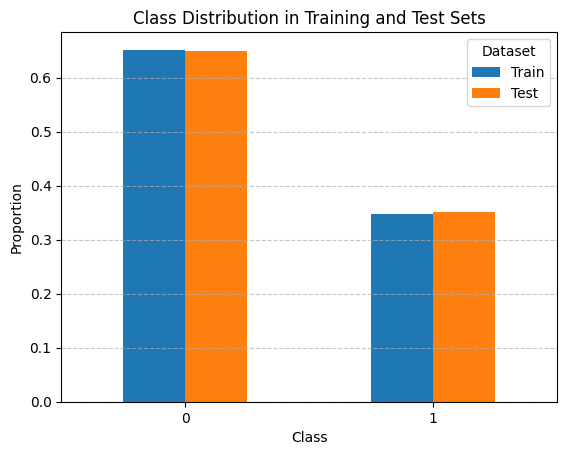

Training set shape: (537, 8)
Test set shape: (231, 8)


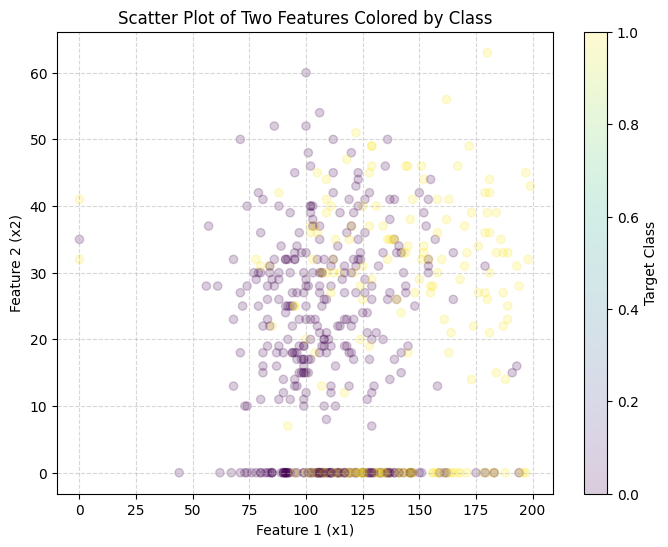

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# Create a directory for saving images
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# Assume df is already loaded
X = df.iloc[:, :-1]  # Select all columns except the last one
y = df.iloc[:, -1]   # Select the last column as the target variable

# Step 1: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,  # 30% test, 70% train
    stratify=y,      # Ensures class distribution remains balanced
    random_state=123 # Fix the random seed for reproducibility
)

# Step 2: Check class distribution in train and test sets
y_train_dist = y_train.value_counts(normalize=True)
y_test_dist = y_test.value_counts(normalize=True)
train_test_dist = pd.DataFrame({'Train': y_train_dist, 'Test': y_test_dist})

# Step 3: Visualize class distribution in training and test sets
plt.figure(figsize=(8,6))
train_test_dist.plot.bar(rot=0)  # Rotate labels for better readability
plt.title("Class Distribution in Training and Test Sets")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.legend(title="Dataset")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.savefig(os.path.join(save_dir, "class_distribution.png"), dpi=300, bbox_inches="tight")  # Save figure
plt.show()

# Step 4: Print the shape of the datasets
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Step 5: Visualizing feature relationships
x1 = X_train.iloc[:, 1]  # Select feature 1
x2 = X_train.iloc[:, 3]  # Select feature 2

plt.figure(figsize=(8,6))
scatter = plt.scatter(x1, x2, alpha=0.2, c=y_train, cmap="viridis")
plt.xlabel("Feature 1 (x1)")
plt.ylabel("Feature 2 (x2)")
plt.title("Scatter Plot of Two Features Colored by Class")
plt.colorbar(scatter, label="Target Class")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(os.path.join(save_dir, "scatter_feature_relationship.png"), dpi=300, bbox_inches="tight")  # Save figure
plt.show()


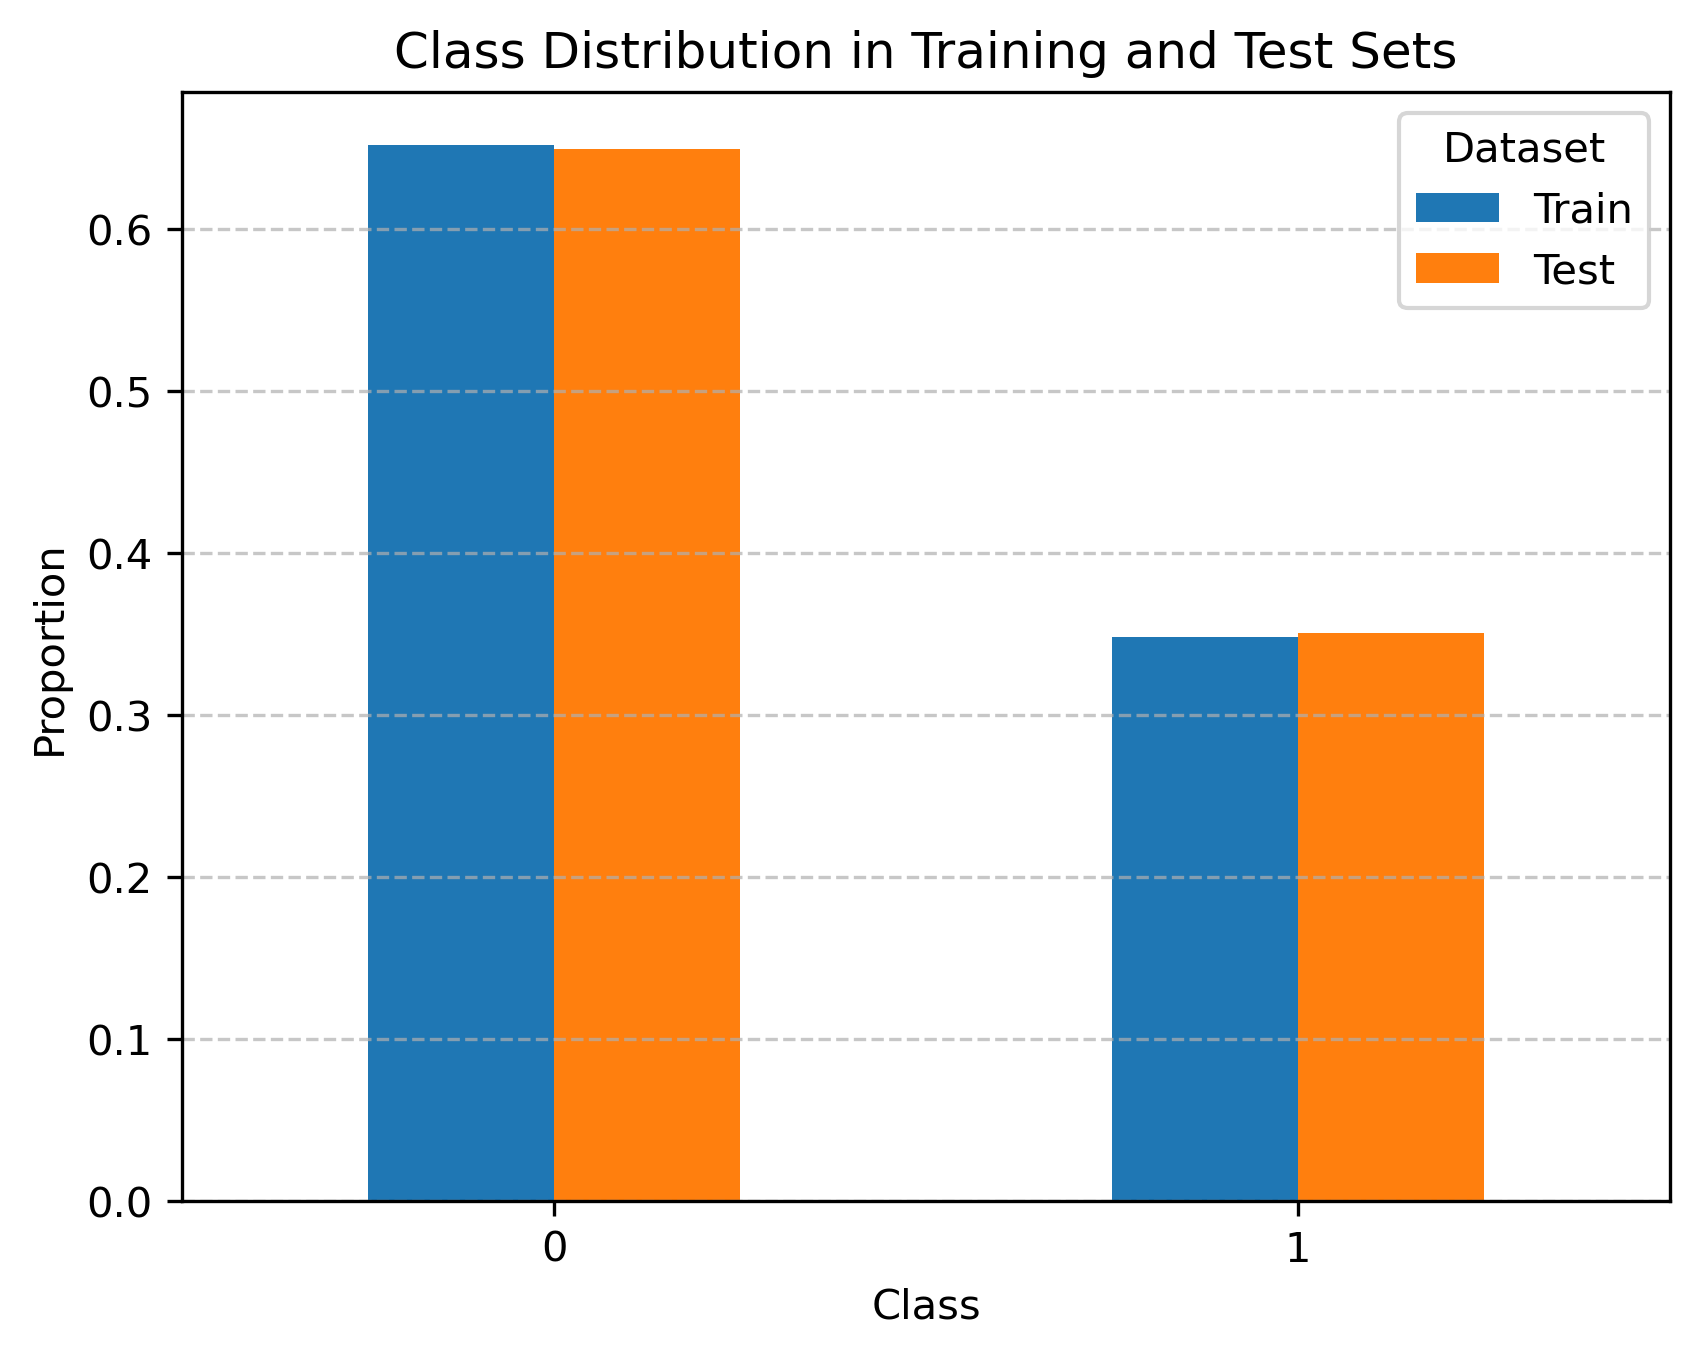

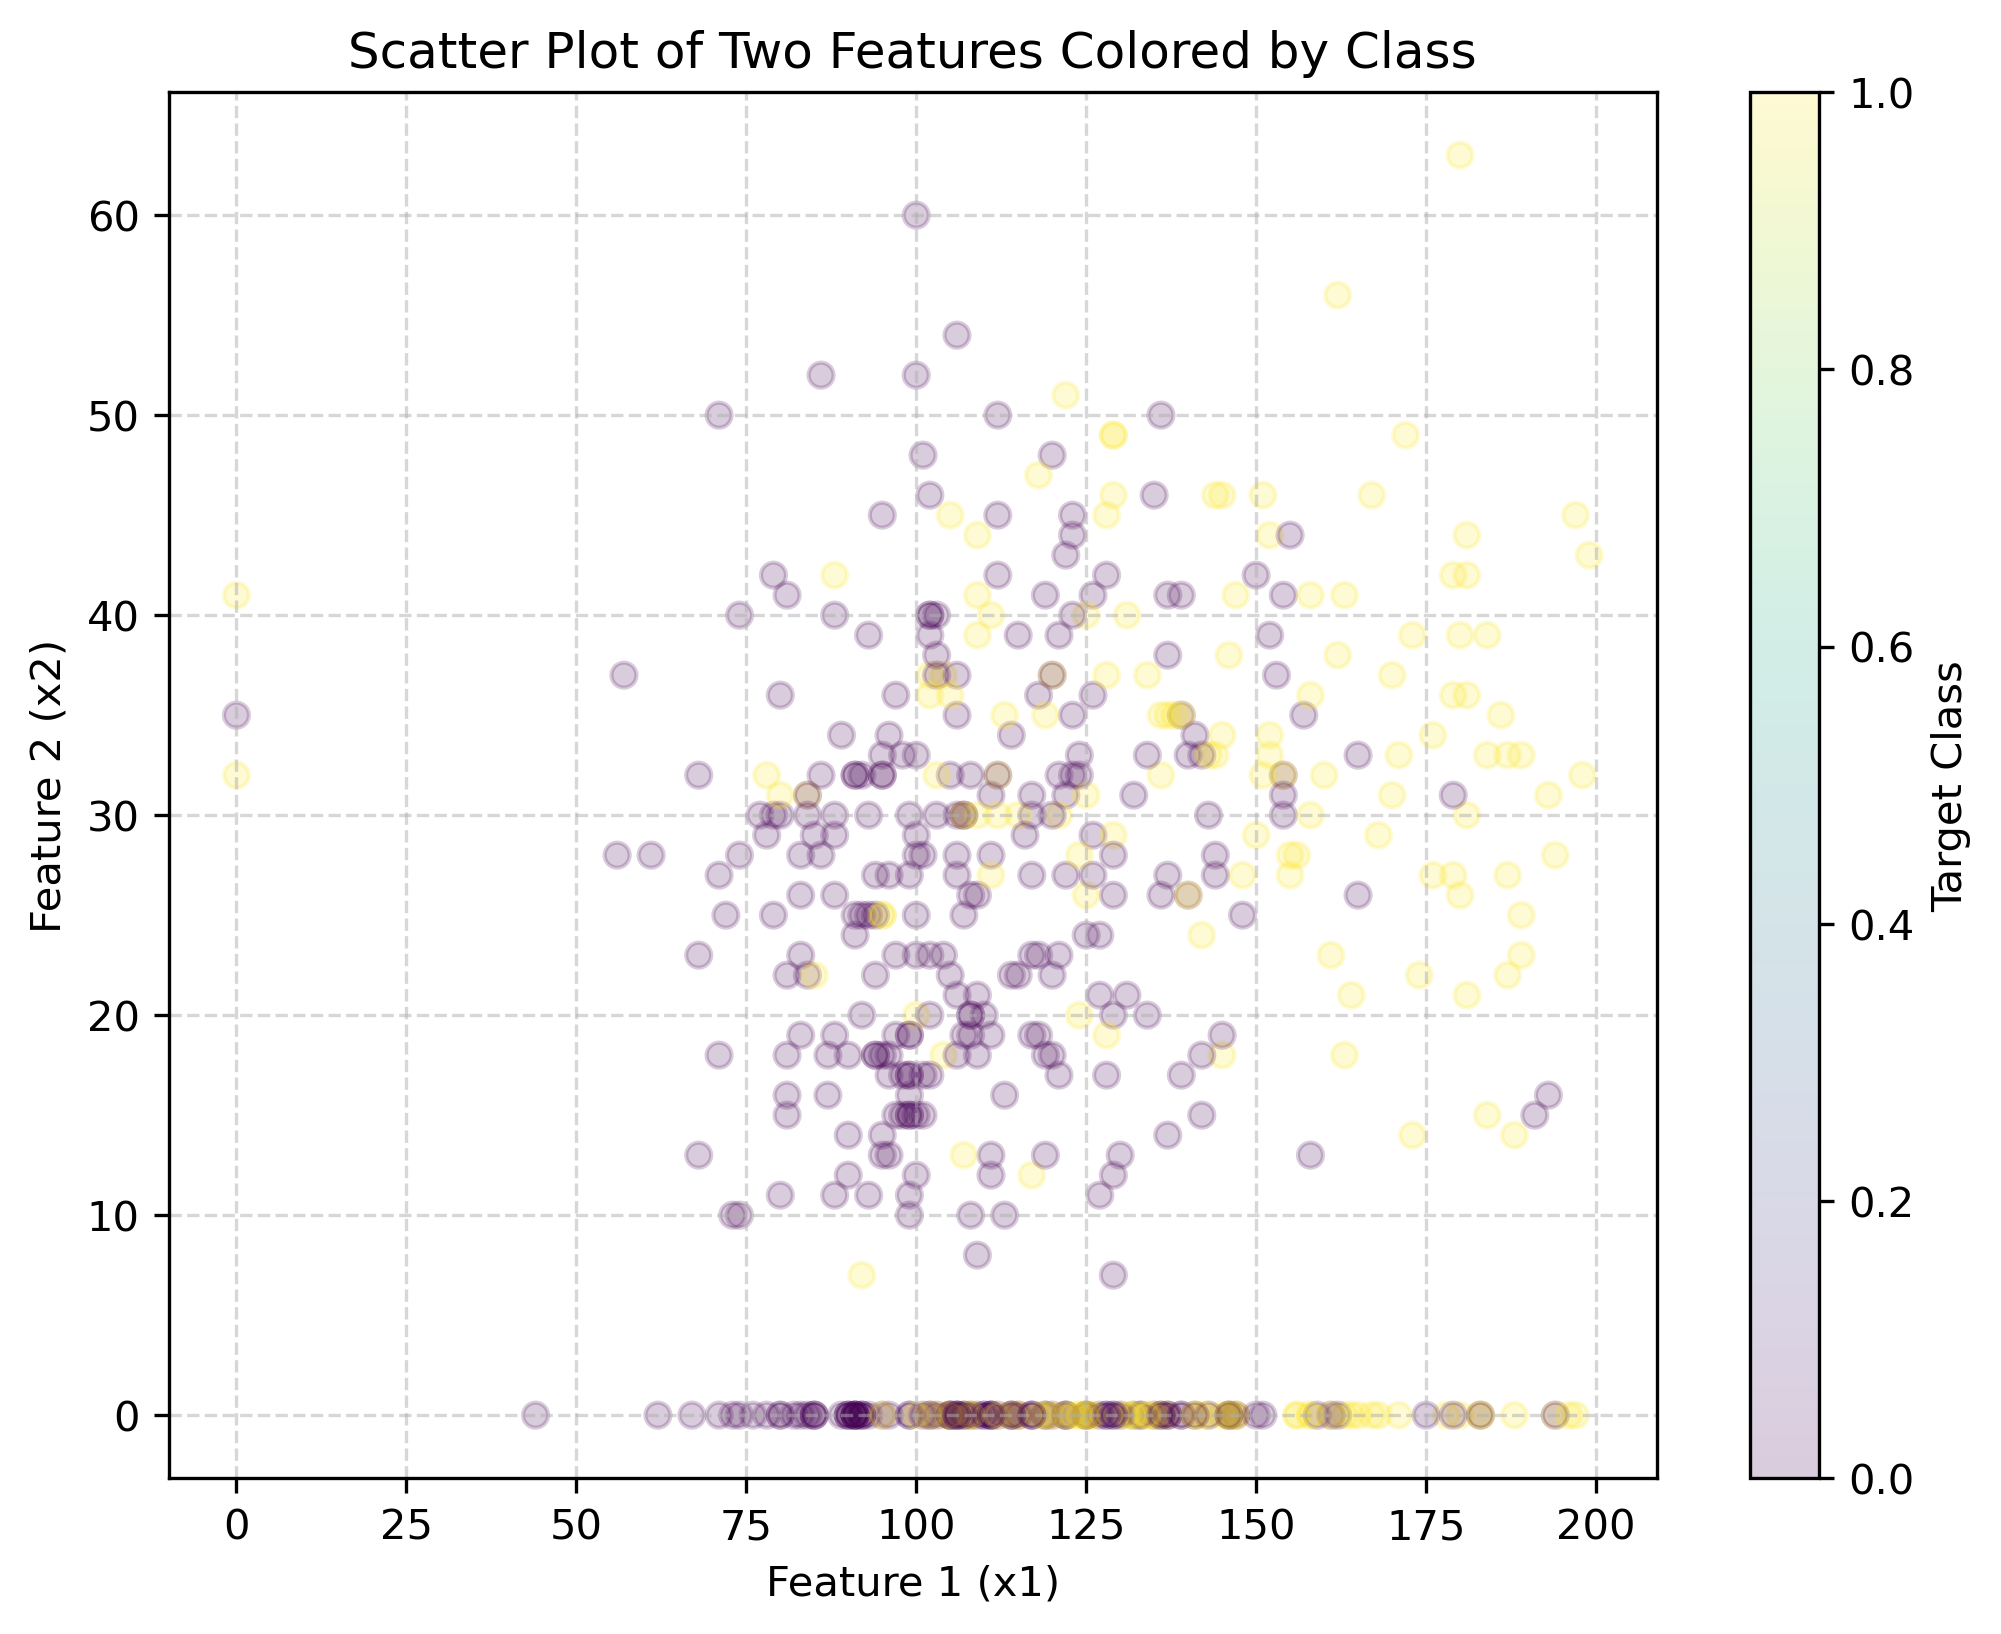

# K-Nearest Neighbor

**Reminder about classification metrics**
![ClassMeasures](classification_measures.png)

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Implementing K-Nearest Neighbors (KNN) & Evaluating Performance**
#### **Objective**
- Use the original dataset **without modification**
- Train a **K-Nearest Neighbors (KNN) classifier**.
- Use **40 neighbors** to classify the test set.
- Evaluate the model using a **confusion matrix** and **visualize results**.

---

### **🔹 Instructions**
1️⃣ **Import necessary libraries**:  
   - Use `KNeighborsClassifier` from `sklearn.neighbors`.
   - Import `confusion_matrix` from `sklearn.metrics`.

2️⃣ **Train the KNN Classifier**:  
   - Define `knn40 = KNeighborsClassifier(n_neighbors=40)`.
   - Train the classifier using `.fit(X_train, y_train)`.  

3️⃣ **Make Predictions**:  
   - Use `.predict(X_test)` to classify test data.

4️⃣ **Evaluate Model Performance**:
   - Compute the **confusion matrix** using `confusion_matrix(y_test, y_pred)`.
   - Visualize the **confusion matrix** using `seaborn.heatmap`.

---


Confusion Matrix:
 [[141   9]
 [ 57  24]]


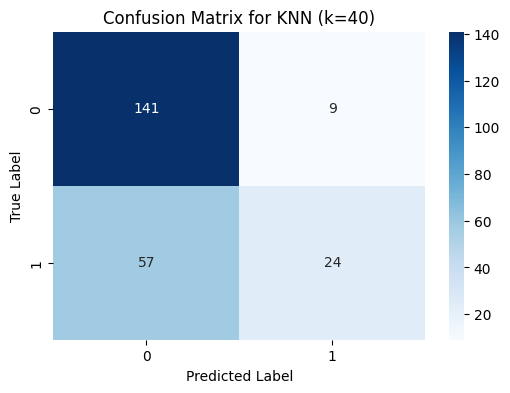

***RESULTS ON TEST SET***
F1 Score: 0.4211
Accuracy: 0.7143
Recall: 0.2963


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score

# Create directory to save figures
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)  # Ensure the directory exists

# Assume X and y are already defined (feature matrix & target variable)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=123
)

# Step 1: Define the classifier
knn40 = KNeighborsClassifier(n_neighbors=40)  # Use 40 neighbors

# Step 2: Train the classifier
knn40.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred = knn40.predict(X_test)

# Step 4: Evaluate performance with a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Step 5: Visualize and save confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for KNN (k=40)")
plt.savefig(os.path.join(save_dir, "confusion_matrix_knn40.png"), dpi=300, bbox_inches="tight")  # Save figure
plt.show()

# Step 6: Compute and display evaluation metrics
print('***RESULTS ON TEST SET***')
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")


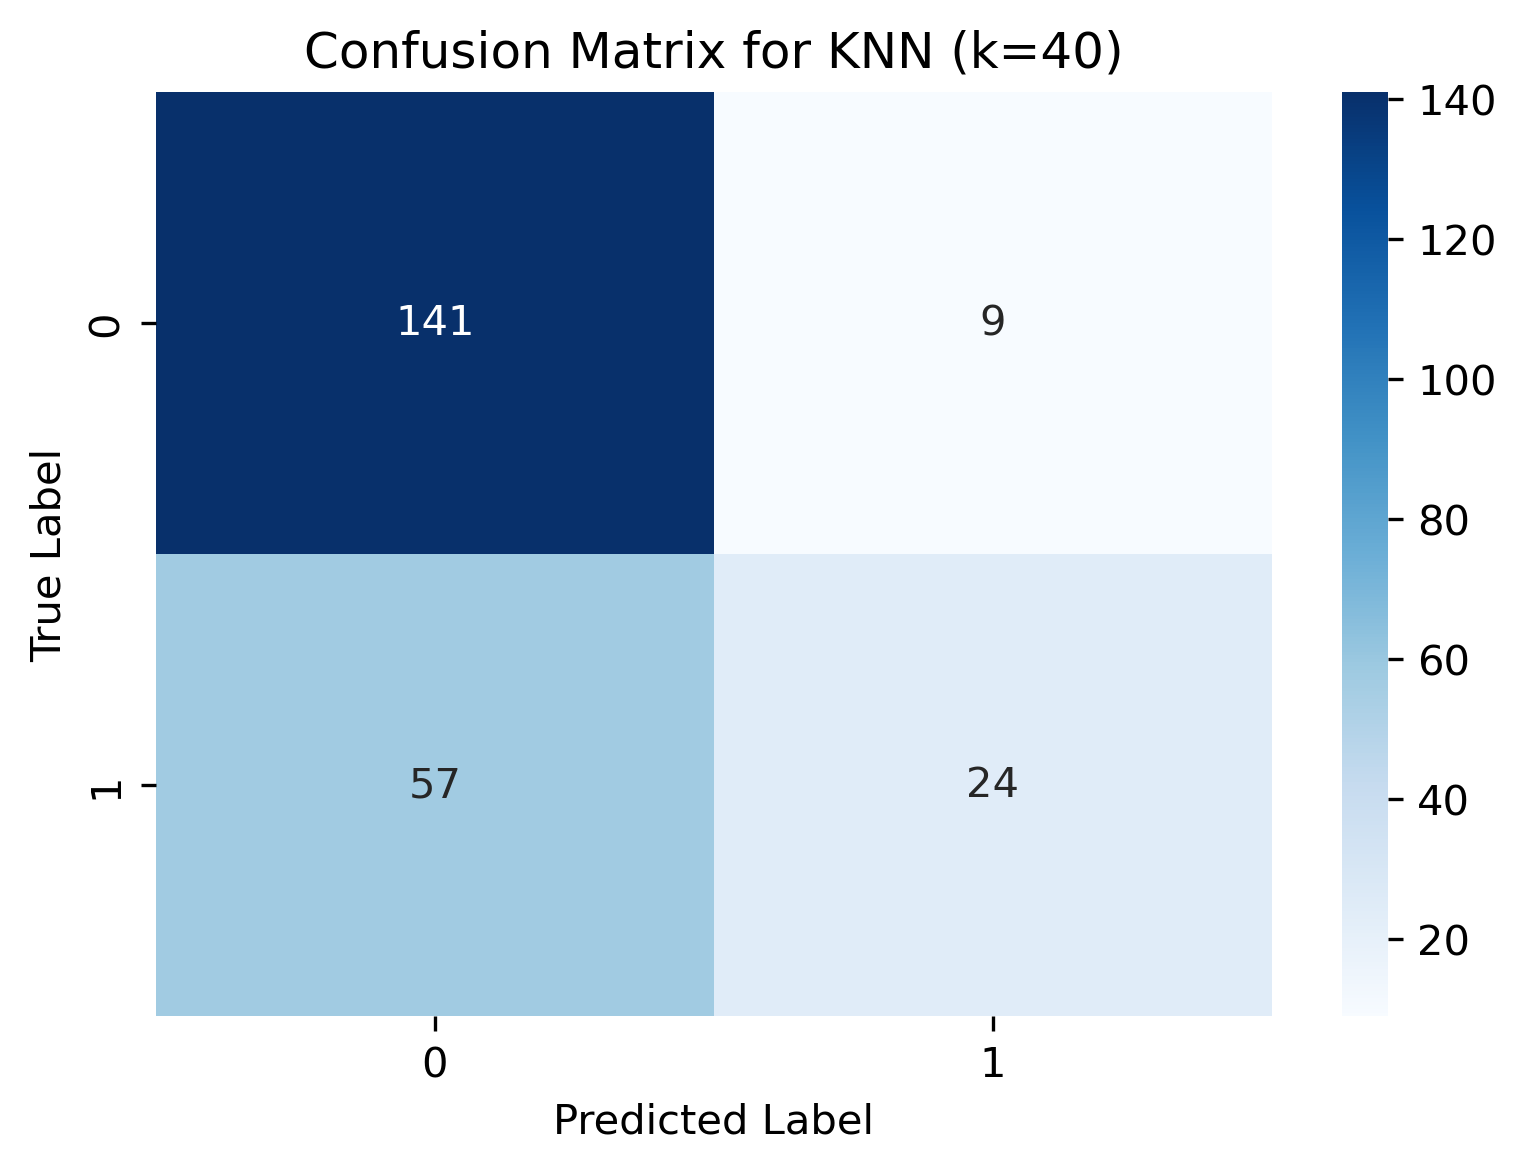

# 🔍 Searching for the Best Parameters in Machine Learning  

## **🛠️ Defining Grid Search (GridSearchCV)**  

**Grid Search (GS)** performs an exhaustive search over a range of specified parameter values for a given estimator. It systematically evaluates different hyperparameter combinations using **cross-validation** to determine the best-performing model.

### **📌 How Grid Search Works**
- Uses **Stratified K-Folds cross-validation**, ensuring that each fold maintains the same class distribution as the dataset.
- Evaluates multiple parameter combinations to find the optimal set.
- Helps in tuning machine learning models for better performance.

---

## **⚙️ Key Parameters of Grid Search**
🔹 **`estimator`**: The machine learning model (e.g., `RandomForestClassifier`, `KNeighborsClassifier`).  
🔹 **`param_grid`**: A dictionary or list of dictionaries specifying hyperparameter values to be tested.  
🔹 **`scoring`**: Evaluation metric used to compare models (e.g., `'accuracy'`, `'f1'`, `'roc_auc'`).  
🔹 **`n_jobs`**: Number of CPU cores used for parallel computation (`-1` uses all available cores).  
🔹 **`cv`**: Number of cross-validation folds (default is `cv=3`).  
🔹 **`verbose`**: Controls the output verbosity (higher values show more details).  

---

## **📈 Why Use Grid Search?**
✅ **Optimizes model performance** by tuning hyperparameters.  
✅ **Ensures better generalization** with cross-validation.  
✅ **Automates hyperparameter selection**, reducing manual tuning effort.  
✅ **Prevents overfitting** by selecting parameters based on multiple data splits.  

🚀 **Next Step:** Implement Grid Search using `sklearn.model_selection.GridSearchCV` to fine-tune your model. 🎯

In [4]:
from sklearn.model_selection import GridSearchCV

#Create KNN Classifier
classifier = KNeighborsClassifier()
parameters = {'n_neighbors':np.arange(1,40)}

gs = GridSearchCV(classifier, parameters, cv=3, scoring = 'f1', verbose=90, n_jobs=-1)

gs = gs.fit(X_train, y_train)

print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("Mean %f Std (%f) with: %r" % (mean, stdev, param))

Fitting 3 folds for each of 39 candidates, totalling 117 fits
Best score: 0.599885 using {'n_neighbors': np.int64(7)}
Mean 0.503441 Std (0.011175) with: {'n_neighbors': np.int64(1)}
Mean 0.416544 Std (0.032890) with: {'n_neighbors': np.int64(2)}
Mean 0.523167 Std (0.053226) with: {'n_neighbors': np.int64(3)}
Mean 0.477595 Std (0.068925) with: {'n_neighbors': np.int64(4)}
Mean 0.557810 Std (0.058966) with: {'n_neighbors': np.int64(5)}
Mean 0.549743 Std (0.041694) with: {'n_neighbors': np.int64(6)}
Mean 0.599885 Std (0.044016) with: {'n_neighbors': np.int64(7)}
Mean 0.562180 Std (0.027379) with: {'n_neighbors': np.int64(8)}
Mean 0.582689 Std (0.038996) with: {'n_neighbors': np.int64(9)}
Mean 0.528314 Std (0.049196) with: {'n_neighbors': np.int64(10)}
Mean 0.571196 Std (0.063104) with: {'n_neighbors': np.int64(11)}
Mean 0.533911 Std (0.072331) with: {'n_neighbors': np.int64(12)}
Mean 0.558187 Std (0.051875) with: {'n_neighbors': np.int64(13)}
Mean 0.513482 Std (0.083722) with: {'n_neighbo

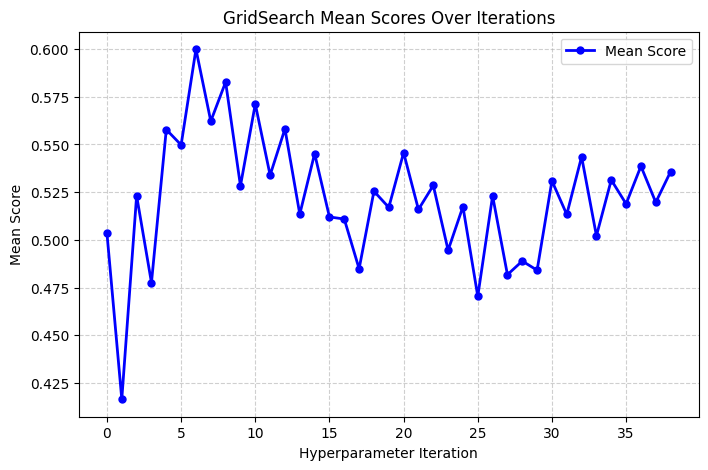

0.5998848467508062


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))  # Set figure size for better readability
plt.plot(means, color='blue', alpha=1.0, marker='o', linestyle='-', linewidth=2, markersize=5, label="Mean Score")

    # Add titles and labels
plt.xlabel("Hyperparameter Iteration")
plt.ylabel("Mean Score")
plt.title("GridSearch Mean Scores Over Iterations")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

    # Save the figure
#plt.savefig("figures/gridsearch_mean_scores.png", dpi=300, bbox_inches="tight")
    
    # Show the plot
plt.show()

print(gs.best_score_)

In [6]:
best_model = gs.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

In [7]:
#EVALUATE YOUR PREDICTION IN THE TRAINING SET
from sklearn import metrics
y_pred_train = best_model.predict(X_train)

print('***RESULTS ON TRAIN SET***')
print("precision: ", metrics.precision_score(y_train, y_pred_train)) # tp / (tp + fp)
print("recall: ", metrics.recall_score(y_train, y_pred_train)) # tp / (tp + fn)
print("f1_score: ", metrics.f1_score(y_train, y_pred_train)) #F1 = 2 * (precision * recall) / (precision + recall)
print("accuracy: ", metrics.accuracy_score(y_train, y_pred_train)) # (tp+tn)/m

print("\n")

print('***RESULTS ON TEST SET***')
print("precision: ", metrics.precision_score(y_test, y_pred)) # tp / (tp + fp)
print("recall: ", metrics.recall_score(y_test, y_pred)) # tp / (tp + fn)
print("f1_score: ", metrics.f1_score(y_test, y_pred)) #F1 = 2 * (precision * recall) / (precision + recall)
print("accuracy: ", metrics.accuracy_score(y_test, y_pred)) # (tp+tn)/m

***RESULTS ON TRAIN SET***
precision:  0.7300613496932515
recall:  0.6363636363636364
f1_score:  0.68
accuracy:  0.7914338919925512


***RESULTS ON TEST SET***
precision:  0.6388888888888888
recall:  0.5679012345679012
f1_score:  0.6013071895424836
accuracy:  0.7359307359307359


In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.83      0.80       150
           1       0.64      0.57      0.60        81

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.70       231
weighted avg       0.73      0.74      0.73       231



# ROC Curve and Train test curve

![ROCcurve](roc_auc.png)

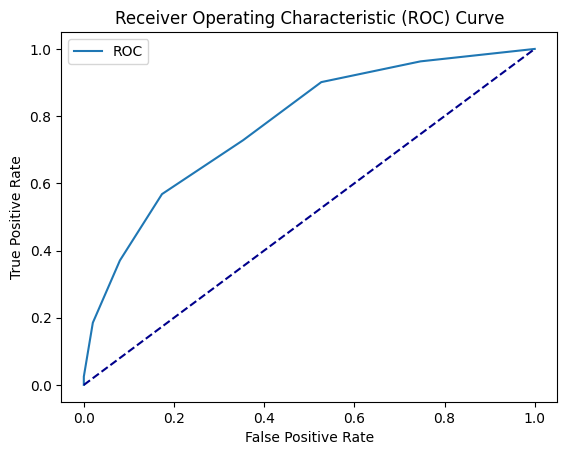

AUC: 0.77


In [9]:
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_probs = model.predict_proba(X_test) #predict_proba gives the probabilities for the target (0 and 1 in your case) 

fpr, tpr, thresholds=metrics.roc_curve(y_test,  y_probs[:,1])

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print('AUC: %.2f' % auc)

![TrainTestCurve](under_overfit.png)

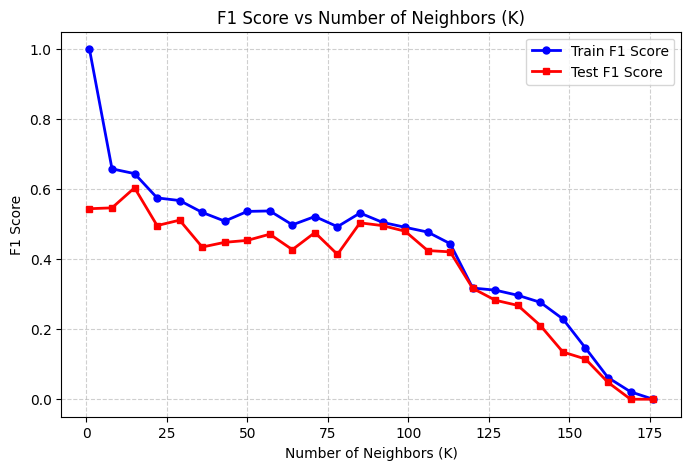

🔥 Best K: 15 | Best F1 Score: 0.6040


In [10]:

# Define range of neighbors to test
neighbors = range(1, 180, 7)

# Lists to store F1 scores
score_train = []
score_test = []

# Loop over different values of k
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    # Compute F1 scores
    f1_train = metrics.f1_score(y_train, y_pred_train)
    f1_test = metrics.f1_score(y_test, y_pred_test)
    
    score_train.append(f1_train)
    score_test.append(f1_test)

# Plot results
plt.figure(figsize=(8,5))  # Set figure size
plt.plot(neighbors, score_train, color='blue', marker='o', linestyle='-', linewidth=2, markersize=5, label="Train F1 Score")
plt.plot(neighbors, score_test, color='red', marker='s', linestyle='-', linewidth=2, markersize=5, label="Test F1 Score")

# Add title and labels
plt.title("F1 Score vs Number of Neighbors (K)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Save the figure
plt.savefig("knn_f1_vs_neighbors.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

# Print best results
best_k = neighbors[np.argmax(score_test)]
best_f1 = max(score_test)
print(f"🔥 Best K: {best_k} | Best F1 Score: {best_f1:.4f}")


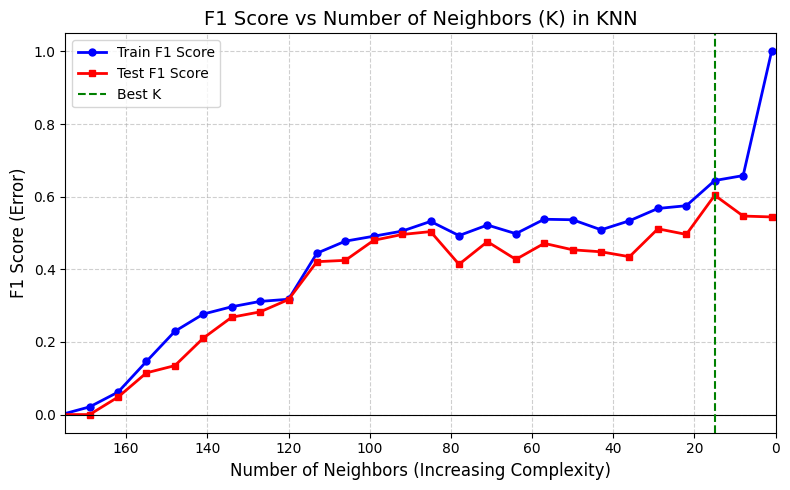

In [11]:

# Plot training and test F1 scores
plt.figure(figsize=(8, 5))  # Set figure size
plt.plot(neighbors, score_train, color='blue', marker='o', linestyle='-', linewidth=2, markersize=5, label="Train F1 Score")
plt.plot(neighbors, score_test, color='red', marker='s', linestyle='-', linewidth=2, markersize=5, label="Test F1 Score")

# Add labels and title
plt.xlabel("Number of Neighbors (Increasing Complexity)", fontsize=12)
plt.ylabel("F1 Score (Error)", fontsize=12)
plt.title("F1 Score vs Number of Neighbors (K) in KNN", fontsize=14)

# Reverse x-axis for better understanding (from low to high complexity)
plt.xlim(175, 0)  # High K on the left (simpler) and low K on the right (more complex)
plt.ylim(-0.05, 1.05)  # Proper range for F1 score

# Add grid, legend, and styling
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(y=0, color="black", linewidth=0.8)  # Horizontal axis reference
plt.axvline(x=neighbors[np.argmax(score_test)], color="green", linestyle="--", label="Best K")  # Best K line
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig("knn_f1_vs_neighbors.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()


<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Applying K-Nearest Neighbors (KNN) on Scaled Data & PCA**
#### **Objective**
- Compare **KNN performance** on **raw data vs. scaled data**.
- Reduce dimensionality using **PCA (2 components vs. all components)**.
- Evaluate the impact of scaling and PCA on **classification accuracy**.

---

## **🔹 Instructions**
### **1️⃣ Preprocess the Data**
🔹 Split the dataset into training and testing sets using `train_test_split`.  
🔹 Scale the features using `StandardScaler` to **improve distance-based classification**.  

### **2️⃣ Apply KNN on Raw & Scaled Data**
🔹 Train and test **KNN (k=10)** on:  
   - **Scaled data** (using `StandardScaler`)  

### **3️⃣ Apply PCA for Dimensionality Reduction**
🔹 Perform PCA with:  
   - **2 Principal Components (PCs)**  
   - **All Principal Components**  
🔹 Train & evaluate **KNN on PCA-transformed data**.  

### **4️⃣ Compare Model Performance**
🔹 Compute accuracy scores and compare **raw vs. scaled vs. PCA-based** results.  


In [12]:
# Initialize and fit the StandardScaler on the full dataset
scaler = StandardScaler().fit(X)

# Function to scale data efficiently
def scale_dataframe(data, scaler, columns):
    """Scales the input dataframe using the provided scaler."""
    scaled_data = scaler.transform(data.astype(float))  # Apply transformation
    scaled_df = pd.DataFrame(scaled_data, columns=columns)  # Convert to DataFrame with correct column names
    return scaled_df

# Scale the entire dataset and training/testing subsets
scaled_X = scale_dataframe(X, scaler, X.columns)
scaled_X_train = scale_dataframe(X_train, scaler, X_train.columns)
scaled_X_test = scale_dataframe(X_test, scaler, X_test.columns)

# Plot boxplot for the scaled features
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
scaled_X.boxplot(rot=45)
plt.title("Boxplot of Scaled Features")
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


NameError: name 'StandardScaler' is not defined

Fitting 3 folds for each of 140 candidates, totalling 420 fits
[CV 1/3; 1/140] START n_neighbors=10............................................
[CV 2/3; 1/140] START n_neighbors=10............................................
[CV 3/3; 1/140] START n_neighbors=10............................................
[CV 1/3; 1/140] END .............n_neighbors=10;, score=0.529 total time=   0.0s
[CV 3/3; 2/140] START n_neighbors=11............................................
[CV 1/3; 2/140] START n_neighbors=11............................................
[CV 2/3; 2/140] START n_neighbors=11............................................
[CV 3/3; 2/140] END .............n_neighbors=11;, score=0.396 total time=   0.0s
[CV 2/3; 3/140] START n_neighbors=12............................................
[CV 1/3; 3/140] START n_neighbors=12............................................
[CV 3/3; 1/140] END .............n_neighbors=10;, score=0.372 total time=   0.0s
[CV 2/3; 1/140] END .............n_neighbors=1

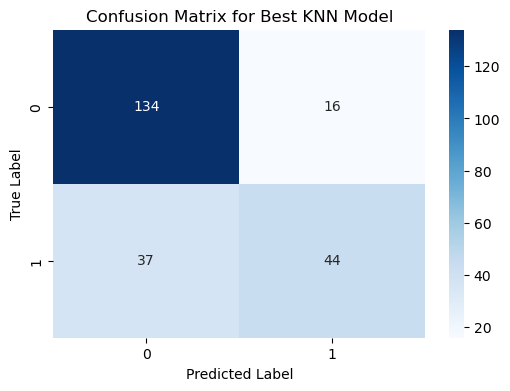

In [ ]:
# Define KNN classifier and parameter grid
classifier = KNeighborsClassifier()
parameters = {'n_neighbors': np.arange(10, 150)}  # Start from 10 to prevent overfitting

# Perform GridSearchCV
gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=10, n_jobs=-1)
gs.fit(scaled_X_train, y_train)

# Best model and predictions
best_model = gs.best_estimator_
y_pred = best_model.predict(scaled_X_test)

# Print best parameters and evaluation metrics
print(f"\n🔹 Best F1 Score: {gs.best_score_:.4f} using {gs.best_params_}")
print(f"🔹 Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"🔹 Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Best KNN Model")

# Save confusion matrix figure
plt.savefig("figures/confusion_matrix_knn.png", dpi=300, bbox_inches="tight")
plt.show()


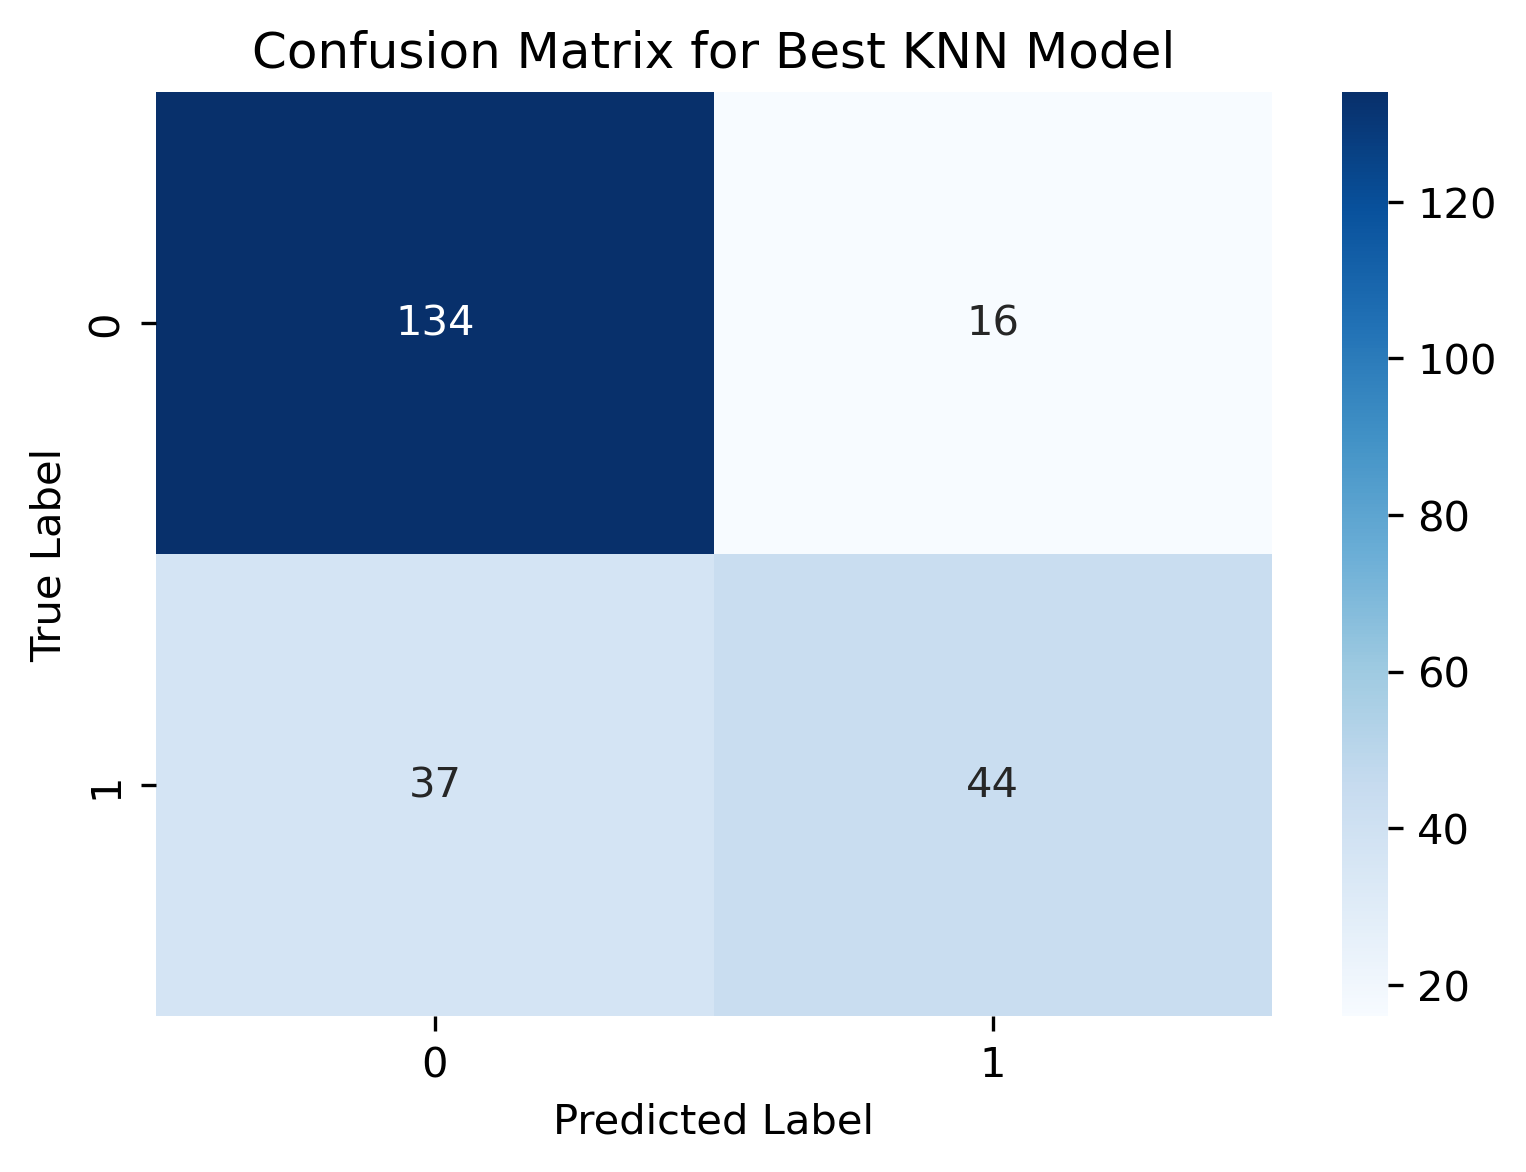

In [ ]:
y_pred_train = best_model.predict(scaled_X_train)

print('***RESULTS ON TRAIN SET***')
print("precision: ", metrics.precision_score(y_train, y_pred_train)) # tp / (tp + fp)
print("recall: ", metrics.recall_score(y_train, y_pred_train)) # tp / (tp + fn)
print("f1_score: ", metrics.f1_score(y_train, y_pred_train)) #F1 = 2 * (precision * recall) / (precision + recall)
print("accuracy: ", metrics.accuracy_score(y_train, y_pred_train)) # (tp+tn)/m
print('---')
print('***RESULTS ON TEST SET***')
print("precision: ", metrics.precision_score(y_test, y_pred)) # tp / (tp + fp)
print("recall: ", metrics.recall_score(y_test, y_pred)) # tp / (tp + fn)
print("f1_score: ", metrics.f1_score(y_test, y_pred)) #F1 = 2 * (precision * recall) / (precision + recall)
print("accuracy: ", metrics.accuracy_score(y_test, y_pred)) # (tp+tn)/m

***RESULTS ON TRAIN SET***
precision:  0.723404255319149
recall:  0.5454545454545454
f1_score:  0.6219512195121951
accuracy:  0.7690875232774674
---
***RESULTS ON TEST SET***
precision:  0.7333333333333333
recall:  0.5432098765432098
f1_score:  0.624113475177305
accuracy:  0.7705627705627706


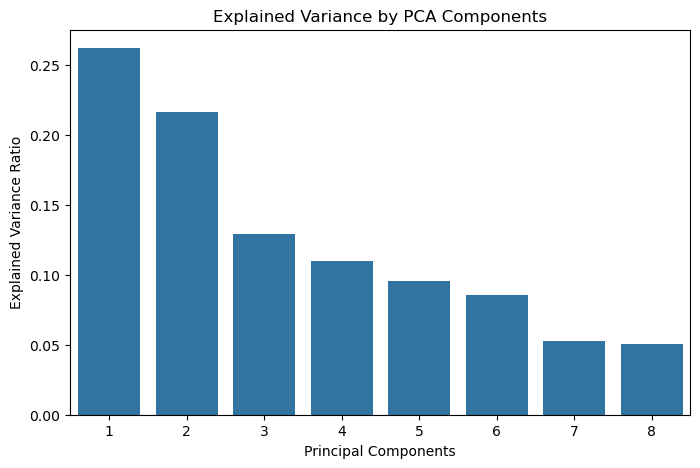


🔹 PCA Components:
    timespreg   gluctol    diaspb   triceps   insulin  massindex  pedigree  \
0   0.128432  0.393083  0.360003  0.439824  0.435026   0.451941  0.270611   
1   0.593786  0.174029  0.183892 -0.331965 -0.250781  -0.100960 -0.122069   
2  -0.013087  0.467923 -0.535494 -0.237674  0.336709  -0.361865  0.433189   
3   0.080691 -0.404329  0.055986  0.037976 -0.349944   0.053646  0.833680   
4  -0.475606  0.466328  0.327953 -0.487862 -0.346935   0.253204  0.119810   
5   0.193598  0.094162 -0.634116  0.009589 -0.270651   0.685372 -0.085784   
6  -0.588790 -0.060153 -0.192118  0.282213 -0.132010  -0.035366 -0.086091   
7   0.117841  0.450355 -0.011296  0.566284 -0.548621  -0.341518 -0.008259   

        age  
0  0.198027  
1  0.620589  
2  0.075248  
3  0.071201  
4 -0.109290  
5 -0.033357  
6  0.712085  
7 -0.211662  
Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5; 1/90] START n_neighbors=10.............................................
[CV 1/5; 1/90] EN

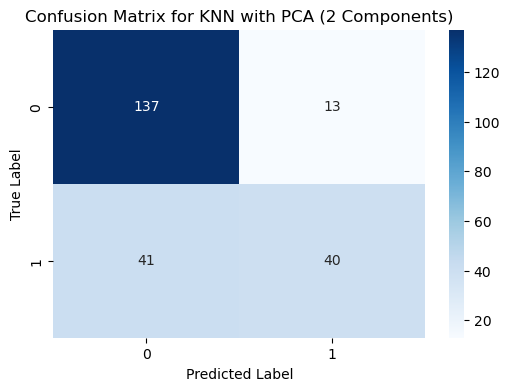

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

# Step 1: Perform PCA
pca = PCA()
pca.fit(scaled_X)

# Transform data using PCA
df_pca = pd.DataFrame(pca.transform(scaled_X))

# Explained Variance Ratio
explained_variance = pd.DataFrame(pca.explained_variance_ratio_, columns=["Explained Variance"])
plt.figure(figsize=(8, 5))
sns.barplot(x=range(1, len(explained_variance) + 1), y=explained_variance["Explained Variance"])
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by PCA Components")
plt.savefig("pca_explained_variance.png", dpi=300, bbox_inches="tight")  # Save figure
plt.show()

# Display PCA components
pca_components = pd.DataFrame(pca.components_, columns=X.columns)
print("\n🔹 PCA Components:\n", pca_components)

# Step 2: Transform Train and Test Data Using PCA
num_pcs = 8  # Adjust the number of principal components
X_pca = pd.DataFrame(pca.transform(scaled_X), columns=[f'PC{i+1}' for i in range(num_pcs)])
X_train_pca = pd.DataFrame(pca.transform(scaled_X_train), columns=[f'PC{i+1}' for i in range(num_pcs)])
X_test_pca = pd.DataFrame(pca.transform(scaled_X_test), columns=[f'PC{i+1}' for i in range(num_pcs)])

# Step 3: Perform Hyperparameter Tuning on KNN
classifier = KNeighborsClassifier()
parameters = {'n_neighbors': np.arange(10, 100)}

gs = GridSearchCV(classifier, parameters, cv=5, scoring='f1', verbose=10, n_jobs=-1)
gs.fit(X_train_pca.iloc[:, :2], y_train)  # Using only first 2 Principal Components

# Step 4: Best Model and Predictions
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_pca.iloc[:, :2])

# Print Best Parameters and Evaluation Metrics
print(f"\n🔹 Best F1 Score: {gs.best_score_:.4f} using {gs.best_params_}")
print(f"🔹 Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"🔹 Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Step 5: Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for KNN with PCA (2 Components)")

# Save Confusion Matrix Figure
plt.savefig("confusion_matrix_knn_pca.png", dpi=300, bbox_inches="tight")
plt.show()


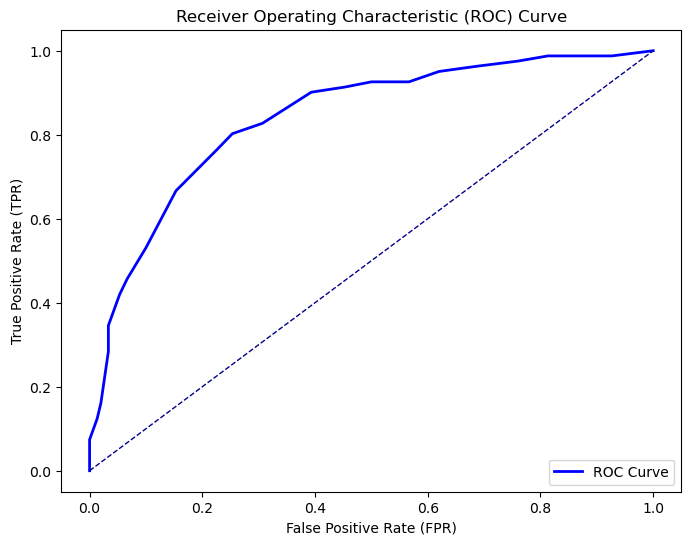

🔹 AUC Score: 0.84


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Step 1: Select the top 3 principal components
X_train_pca_3 = X_train_pca.iloc[:, :3]
X_test_pca_3 = X_test_pca.iloc[:, :3]

# Step 2: Initialize and Train KNN Classifier
model = KNeighborsClassifier(n_neighbors=27)
model.fit(X_train_pca_3, y_train)

# Step 3: Make Predictions
y_pred = model.predict(X_test_pca_3)
y_probs = model.predict_proba(X_test_pca_3)[:, 1]  # Probabilities for class 1

# Step 4: Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Step 5: Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color="blue", lw=2)
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', lw=1)  # Diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Save the ROC figure
plt.savefig("ROC_Curve_KNN_PCA.png", dpi=300, bbox_inches="tight")
plt.show()

# Step 6: Compute AUC Score
auc_score = roc_auc_score(y_test, y_probs)
print(f"🔹 AUC Score: {auc_score:.2f}")


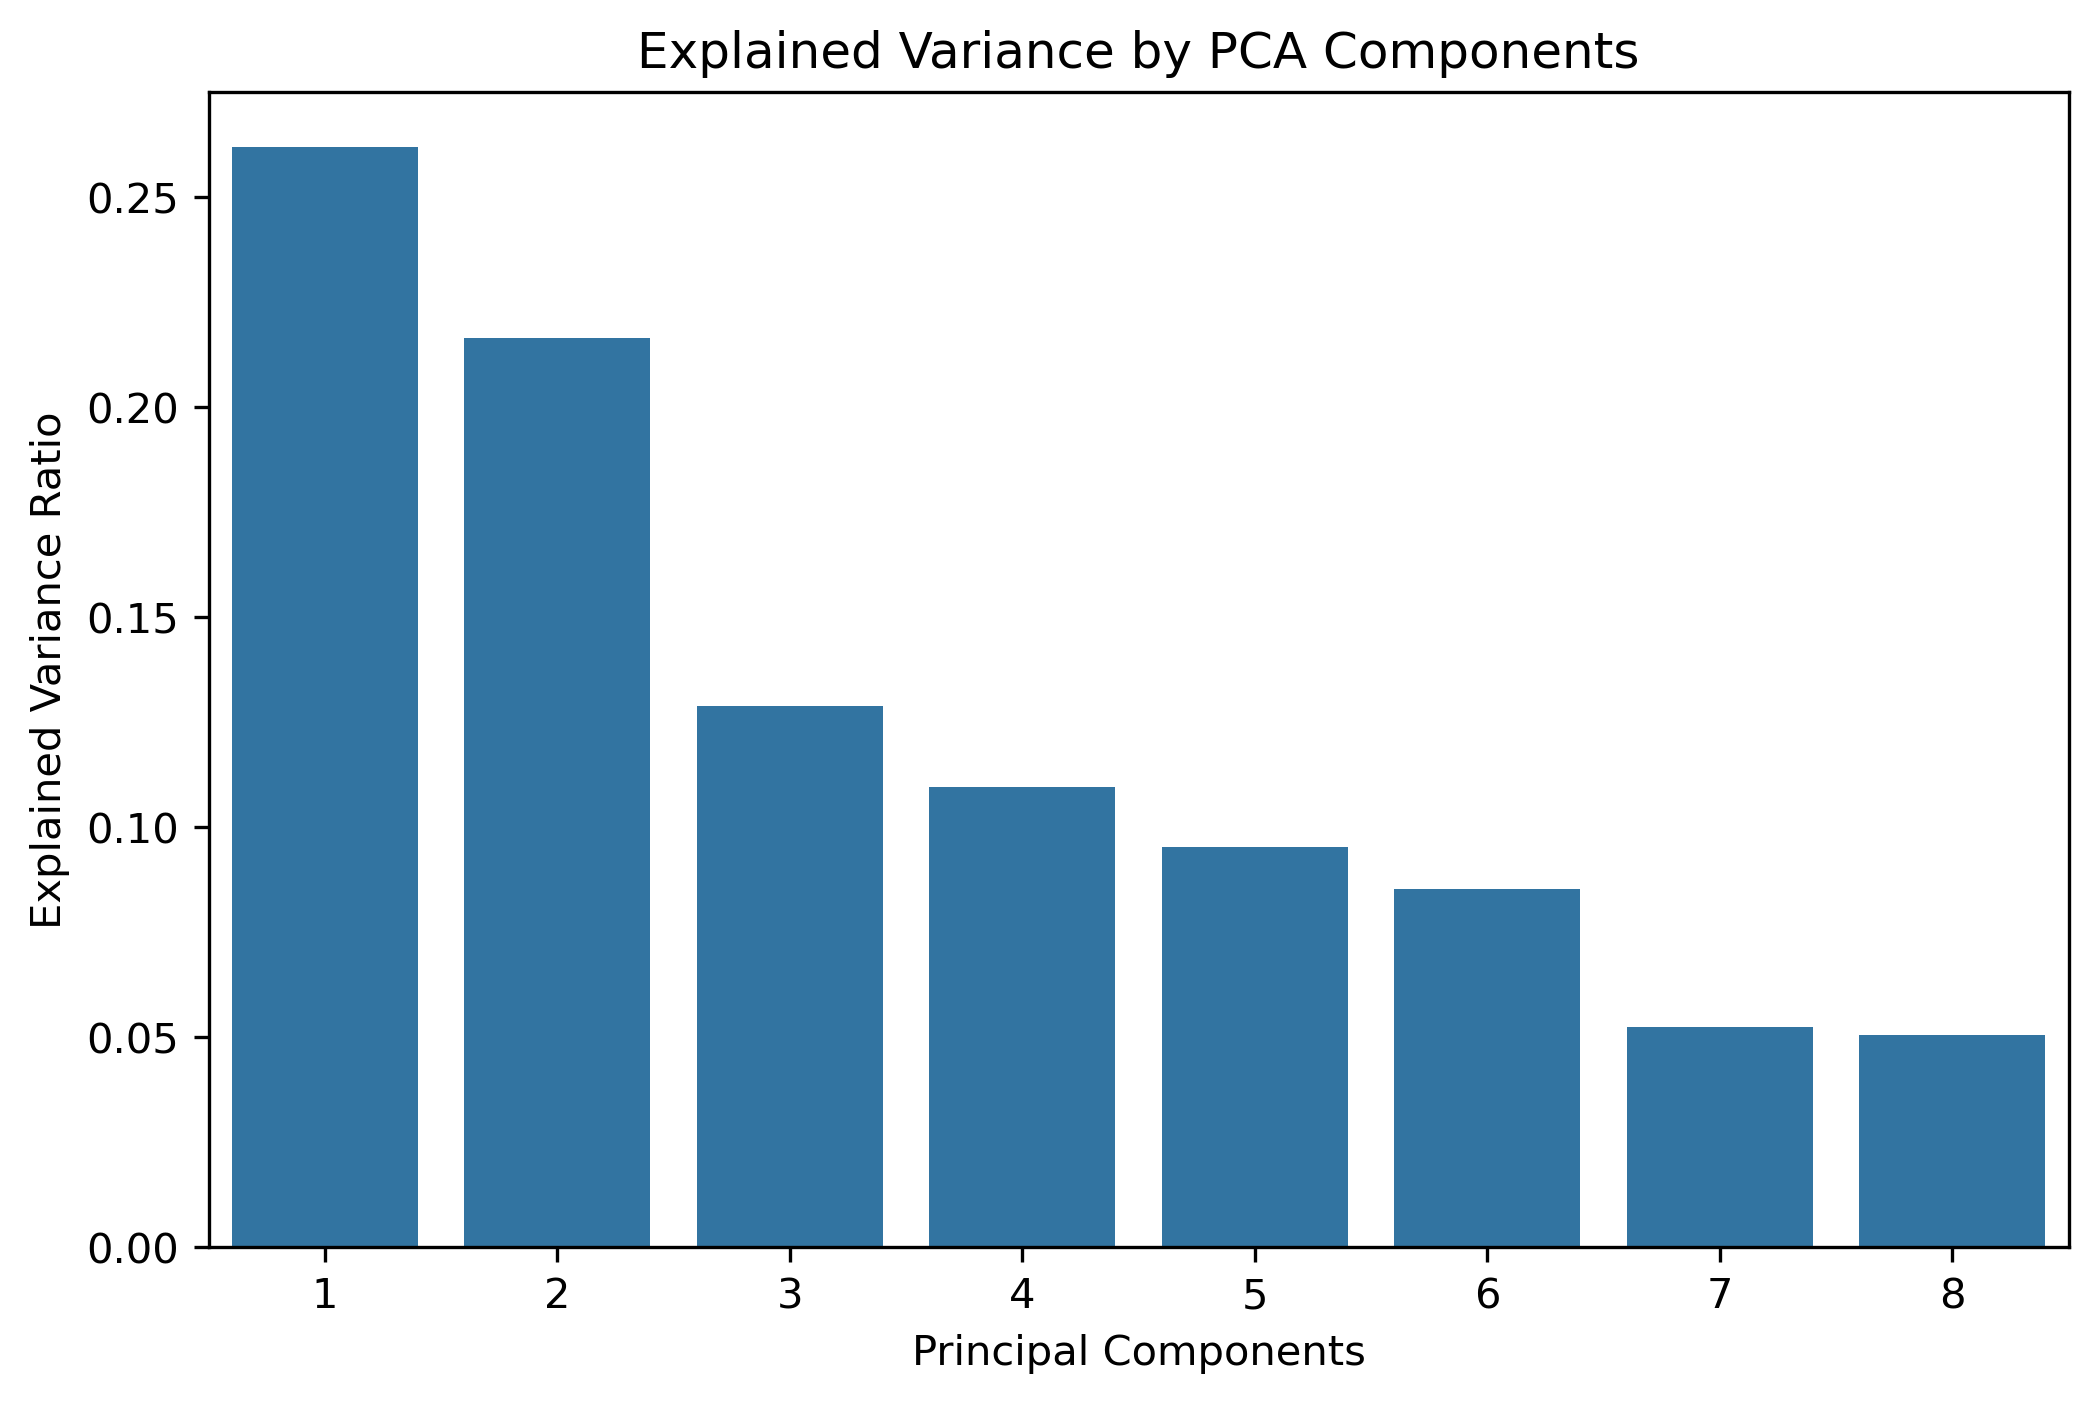

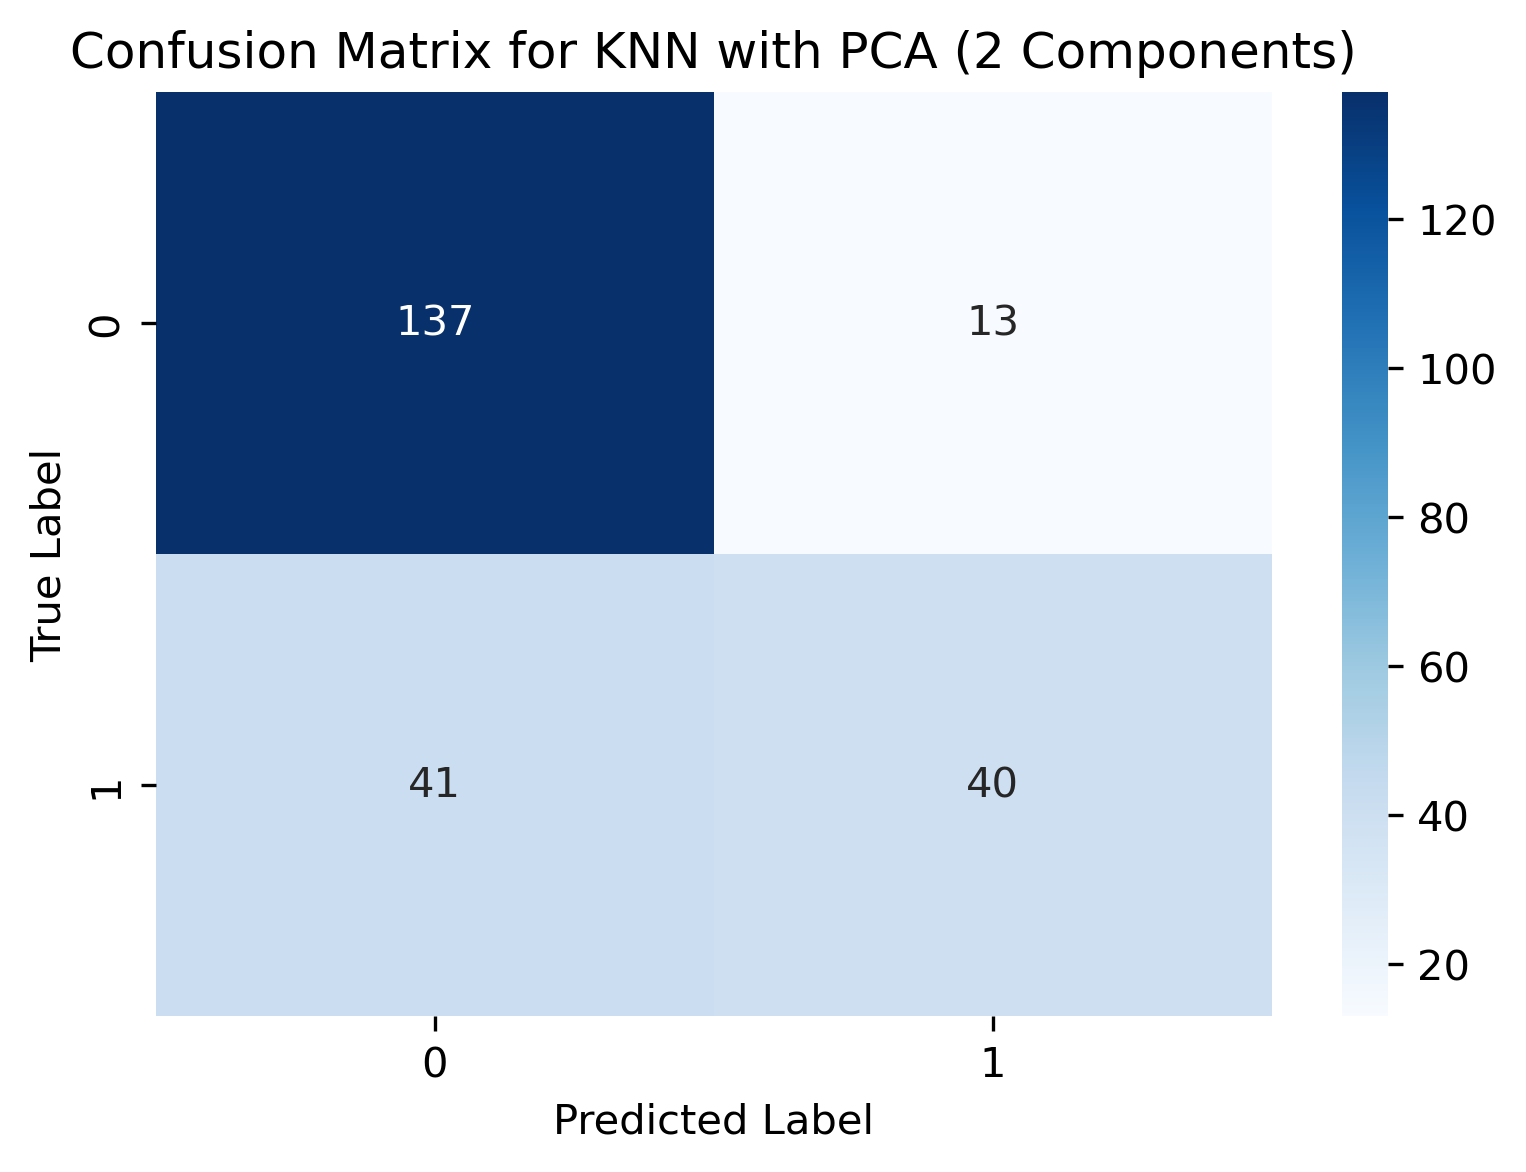

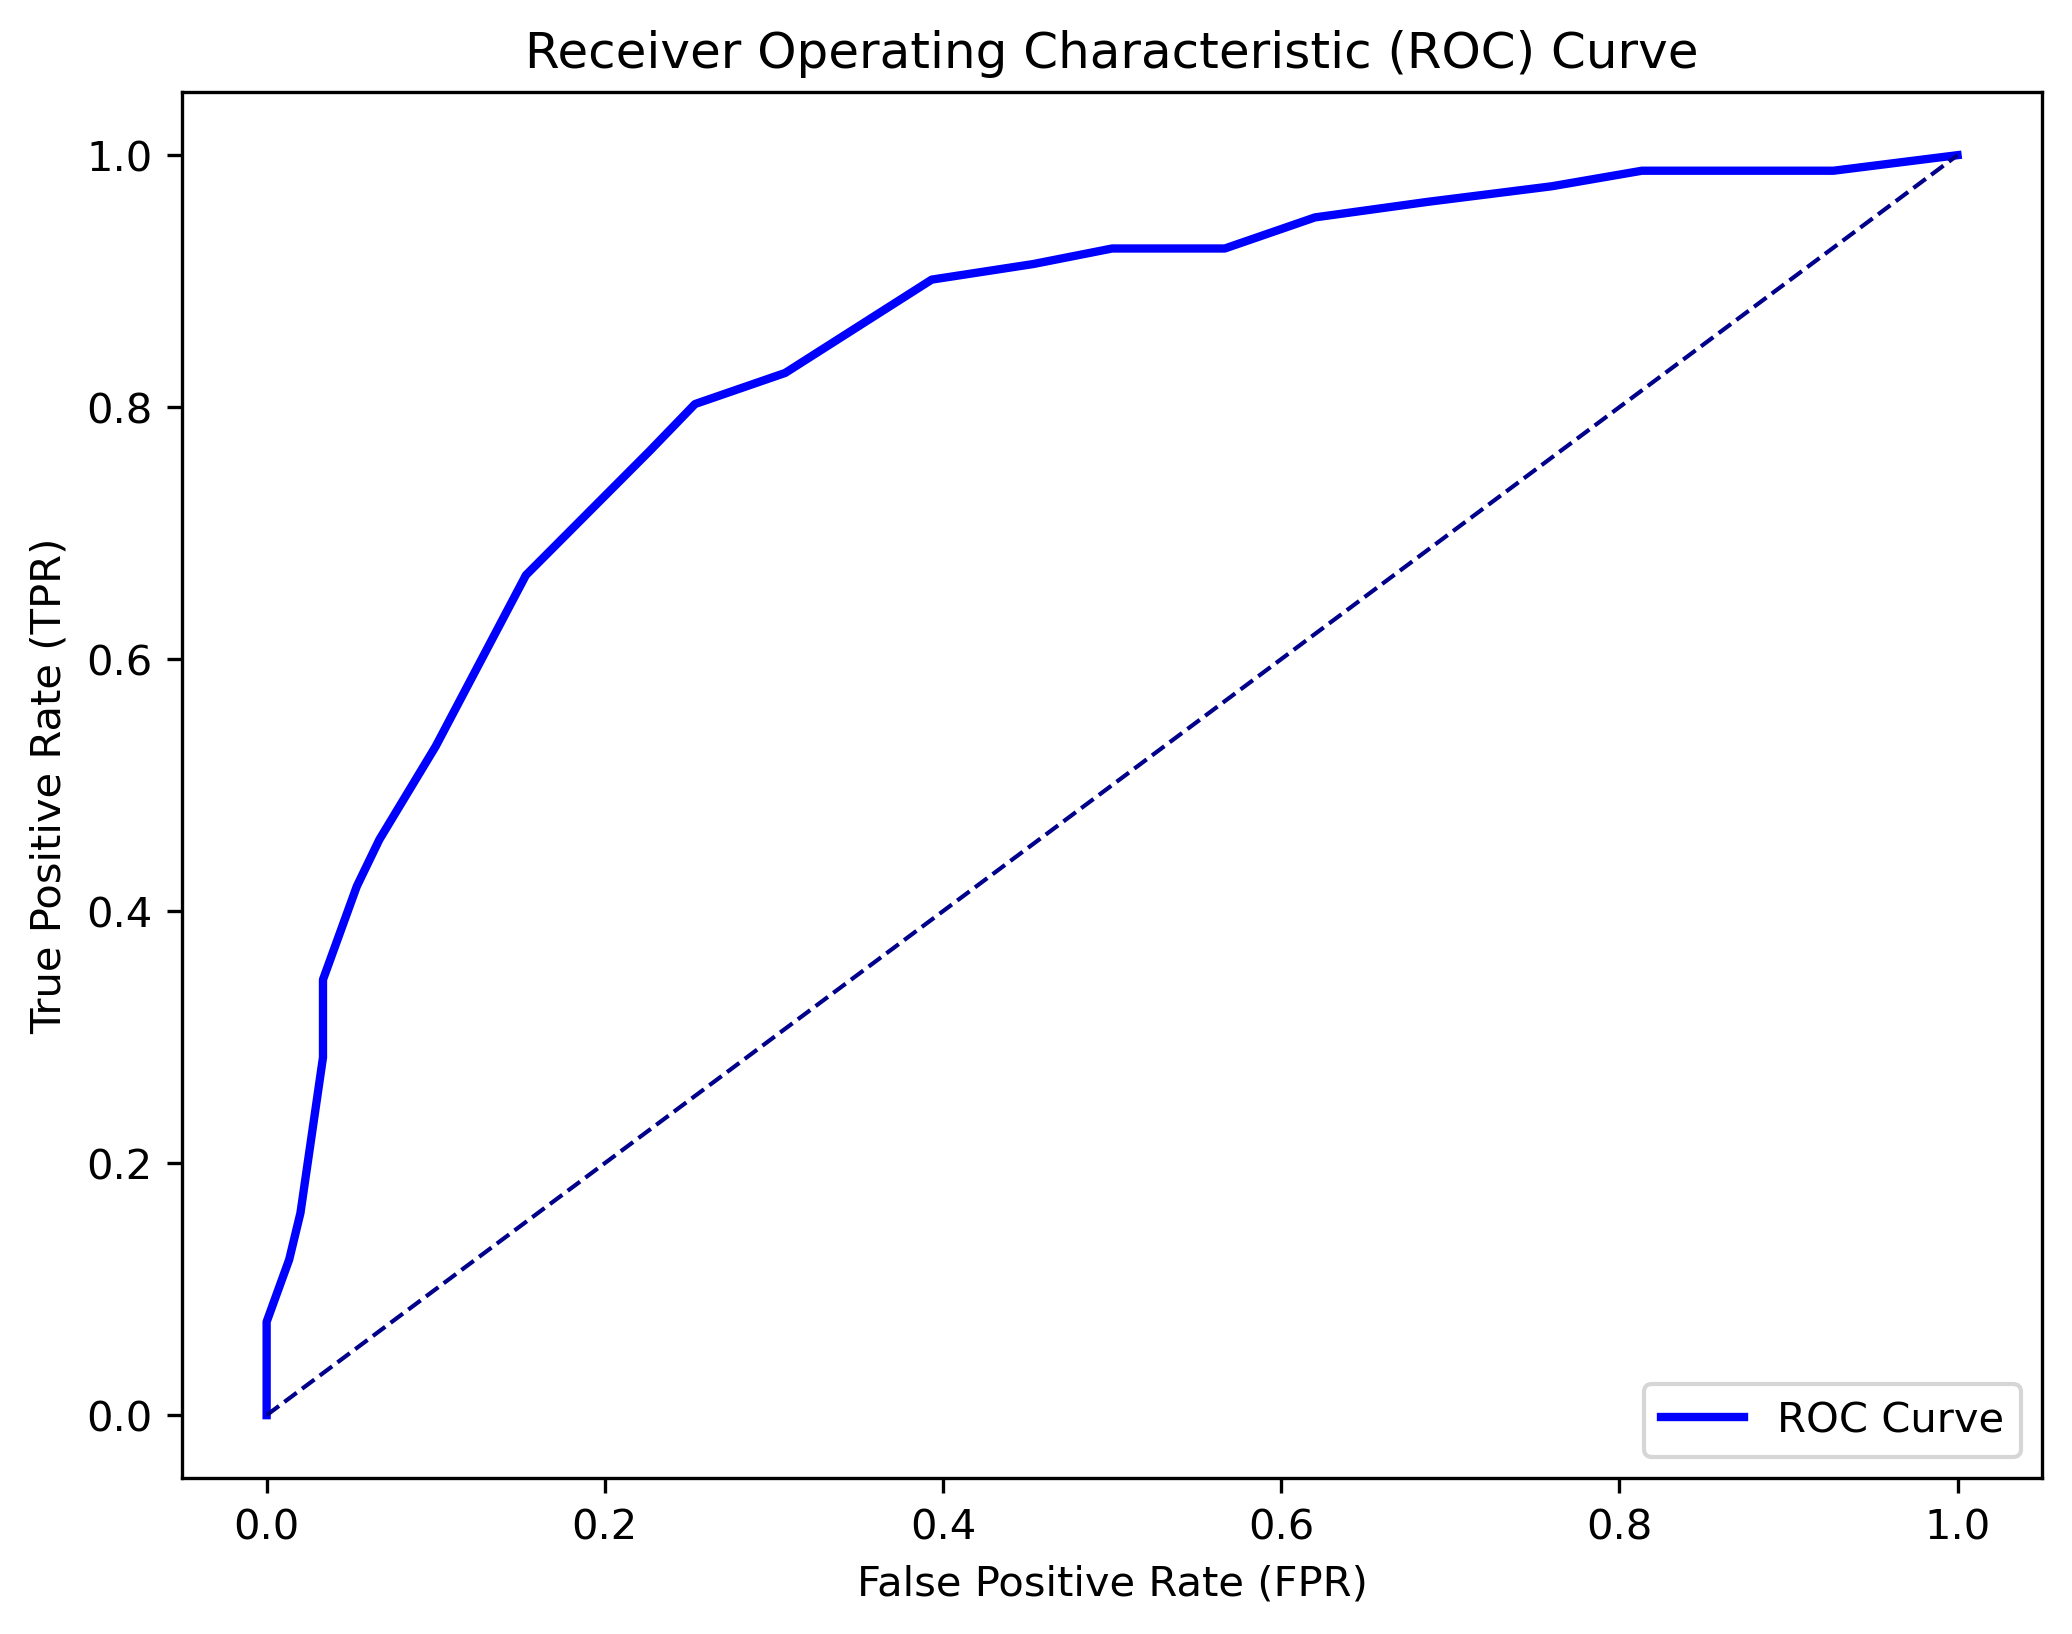